# DenSHAP — Publication-Quality Figure Generation

Generates all figures for journal submission (PNG at 600 DPI + PDF vector).  
Captions are intentionally omitted; add them via `\caption{}` in LaTeX.

| Figure | Filename | Content |
|--------|----------|---------|
| Fig 1 | `fig1_overall_ca_bds` | CA$_{\text{top1}}$ & BDS across all five methods (2×3 grid) |
| Fig 2 | `fig2_bds_by_group` | BDS by difficulty group (Easy / Medium / Hard) |
| Fig 3 | `fig3_lof_distribution` | LOF score distribution per dataset (box + jitter) |
| Fig 4 | `fig4_bds_delta_violin` | Per-instance ΔBDS violin (DenSHAP − CF-SHAP) |
| Fig 5 | `fig5_alpha_vs_delta_bds` | Difficulty score α vs. ΔBDS scatter |
| Fig 6 | `fig6_plausibility` | Plausibility boxplot with Wilcoxon significance brackets |

## 0. Environment Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from scipy import stats
import os

# ── Output directory ──────────────────────────────────────────────────────────
FIGURE_DIR = './figures/klof20'          # Change to your preferred output path
os.makedirs(FIGURE_DIR, exist_ok=True)

# ── CSV input directory ───────────────────────────────────────────────────────
BASE = 'results/klof20'                        # Directory containing all CSV files

# ── Global Matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 9,
    'axes.titlesize'    : 10,
    'axes.labelsize'    : 9,
    'xtick.labelsize'   : 8,
    'ytick.labelsize'   : 8,
    'axes.linewidth'    : 0.7,
    'xtick.major.width' : 0.7,
    'ytick.major.width' : 0.7,
    'axes.grid'         : True,
    'grid.linewidth'    : 0.4,
    'grid.alpha'        : 0.35,
    'grid.color'        : '#aaaaaa',
    'legend.fontsize'   : 8,
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#cccccc',
    'figure.dpi'        : 150,    # Preview DPI inside the notebook
    'savefig.dpi'       : 600,    # Export DPI for saved files
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.08,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C_CF   = '#7B6FBE'   # CF-SHAP baseline    — muted purple
C_DEN  = '#2A7F5F'   # DenSHAP (ours)      — dark teal
C_EASY = '#5B9BD5'   # Easy difficulty group
C_MED  = '#F4A03A'   # Medium difficulty group
C_HARD = '#D95F5F'   # Hard difficulty group

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
# ── Per-instance result files ─────────────────────────────────────────────────
heloc_cf  = pd.read_csv(f'{BASE}/heloc_cfshap.csv')
heloc_den = pd.read_csv(f'{BASE}/heloc_denshap.csv')
wine_cf   = pd.read_csv(f'{BASE}/wine_cfshap.csv')
wine_den  = pd.read_csv(f'{BASE}/wine_denshap.csv')
lc_cf     = pd.read_csv(f'{BASE}/lendingclub_cfshap.csv')
lc_den    = pd.read_csv(f'{BASE}/lendingclub_denshap.csv')

# ── Aggregate summary files (method-level means) ──────────────────────────────
heloc_sum = pd.read_csv(f'{BASE}/heloc_summary.csv')
wine_sum  = pd.read_csv(f'{BASE}/wine_summary.csv')
lc_sum    = pd.read_csv(f'{BASE}/lendingclub_summary.csv')

# ── BDS by difficulty group files ─────────────────────────────────────────────
heloc_bds = pd.read_csv(f'{BASE}/heloc_bds_by_group.csv')
wine_bds  = pd.read_csv(f'{BASE}/wine_bds_by_group.csv')
lc_bds    = pd.read_csv(f'{BASE}/lendingclub_bds_by_group.csv')

# ── Shared constants ──────────────────────────────────────────────────────────
# Keys must match the 'Method' column values in summary CSVs
METHOD_KEYS    = ['SHAP_TRAIN', 'SHAP_D_LAB', 'SHAP_D_PRED', 'CF_SHAP', 'DenSHAP (ours)']
# Display labels for x-axis ticks (newline for compactness)
METHODS_LABELS = ['SHAP\nTRAIN', 'SHAP\nD-LAB', 'SHAP\nD-PRED', 'CF-SHAP', 'DenSHAP\n(ours)']
BAR_COLORS     = ['#AAAAAA', '#999999', '#888888', C_CF, C_DEN]
BAR_HATCHES    = ['', '', '', '', '///']   # Hatch on DenSHAP for B&W print compatibility

TITLES  = ['HELOC', 'Wine Quality', 'LendingClub']
SUMS    = [heloc_sum, wine_sum, lc_sum]
GROUPS  = ['Easy', 'Medium', 'Hard']
BDS_DFS = [heloc_bds, wine_bds, lc_bds]

print('Data loaded successfully.')
heloc_sum

Data loaded successfully.


,Method,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,BDS
0,SHAP_TRAIN,9.478934,9.222173,9.046204,8.953387,1.679187,0.943319
1,SHAP_D_LAB,9.326649,8.999210,8.846196,8.766272,1.661609,0.944395
2,SHAP_D_PRED,9.244166,8.902553,8.731005,8.660769,1.654998,0.943799
3,CF_SHAP,9.195533,8.993128,8.806278,8.746769,1.506315,0.964696
4,DenSHAP (ours),9.124886,8.880004,8.726658,8.625340,1.435131,0.971989


## Fig 1 — Overall CA$_{\text{top1}}$ and BDS Comparison (2 × 3 grid)

Rows: CA$_{\text{top1}}$ (top) and BDS (bottom). Columns: HELOC, Wine Quality, LendingClub.  
DenSHAP bars are highlighted with a dark-teal border and diagonal hatching for B&W print legibility.

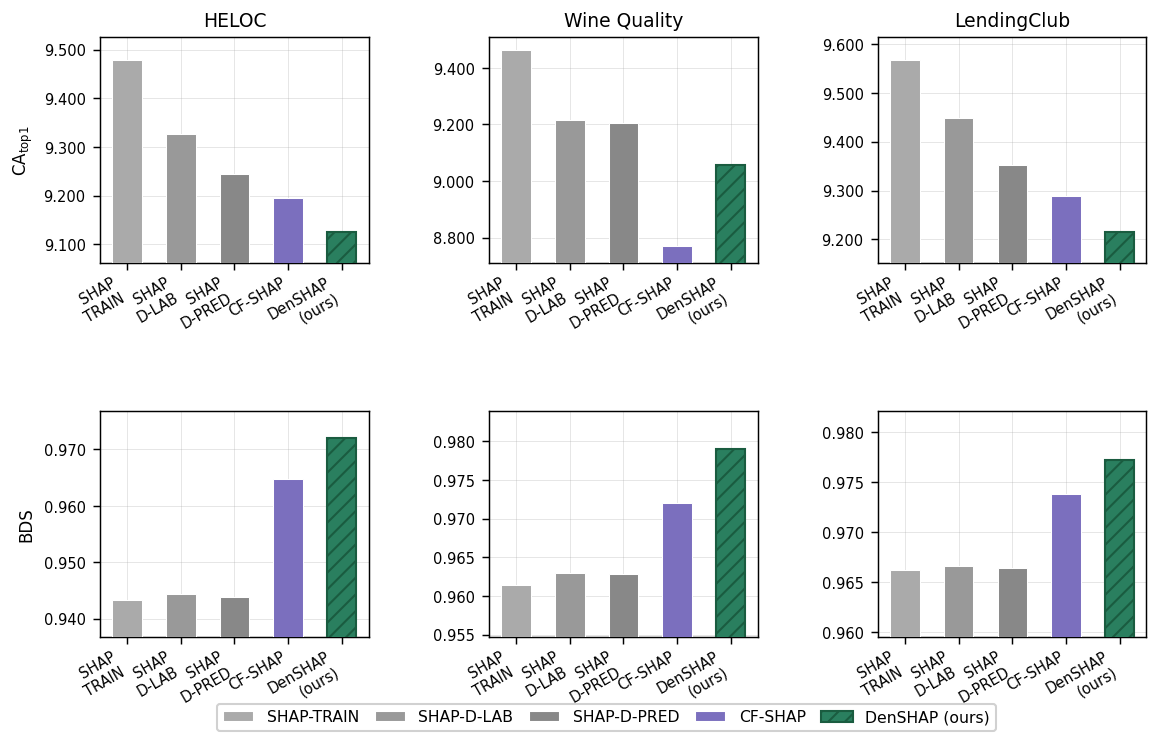

Fig 1 saved.


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9.0, 5.2))
fig.subplots_adjust(hspace=0.65, wspace=0.45)

for col, (sumdf, title) in enumerate(zip(SUMS, TITLES)):
    for row, metric in enumerate(['CA_top1', 'BDS']):
        ax   = axes[row][col]
        vals = [sumdf.loc[sumdf['Method'] == m, metric].values[0] for m in METHOD_KEYS]
        x    = np.arange(len(METHODS_LABELS))

        bars = ax.bar(x, vals, width=0.55, color=BAR_COLORS,
                      edgecolor='white', linewidth=0.5, zorder=3)

        # Apply hatch pattern to each bar
        for bar, hatch in zip(bars, BAR_HATCHES):
            bar.set_hatch(hatch)

        # Highlight DenSHAP bar with a distinct border
        bars[-1].set_edgecolor('#1a5c40')
        bars[-1].set_linewidth(1.0)

        # Set y-axis limits with a small margin
        ax.set_ylim(min(vals) * 0.993, max(vals) * 1.005)
        ax.set_xticks(x)
        # Rotate labels 30° to prevent overlap across five methods
        ax.set_xticklabels(METHODS_LABELS, fontsize=7, rotation=30, ha='right')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', pad=2)
        ax.set_axisbelow(True)

        if row == 0:
            ax.set_title(title, fontsize=9, fontweight='normal', pad=5)
        if col == 0:
            # Use LaTeX notation for the metric label
            ylabel = r'CA$_{\mathrm{top1}}$' if metric == 'CA_top1' else 'BDS'
            ax.set_ylabel(ylabel, fontsize=8)

# Shared legend below all subplots
legend_patches = [
    mpatches.Patch(facecolor='#AAAAAA', edgecolor='white', label='SHAP-TRAIN'),
    mpatches.Patch(facecolor='#999999', edgecolor='white', label='SHAP-D-LAB'),
    mpatches.Patch(facecolor='#888888', edgecolor='white', label='SHAP-D-PRED'),
    mpatches.Patch(facecolor=C_CF,  edgecolor='white',   label='CF-SHAP'),
    mpatches.Patch(facecolor=C_DEN, edgecolor='#1a5c40', hatch='///', label='DenSHAP (ours)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.02), fontsize=7.5,
           framealpha=0.9, edgecolor='#cccccc', columnspacing=1.0)

plt.savefig(f'{FIGURE_DIR}/fig1_overall_ca_bds.pdf', format='pdf')
plt.savefig(f'{FIGURE_DIR}/fig1_overall_ca_bds.png', format='png', dpi=600)
plt.show()
print('Fig 1 saved.')

## Fig 2 — BDS by Difficulty Group (Easy / Medium / Hard)

Grouped bar chart comparing CF-SHAP (semi-transparent) and DenSHAP (hatched) within each difficulty group.  
`***` denotes Wilcoxon signed-rank test significance at p < 0.001 for the Hard group.

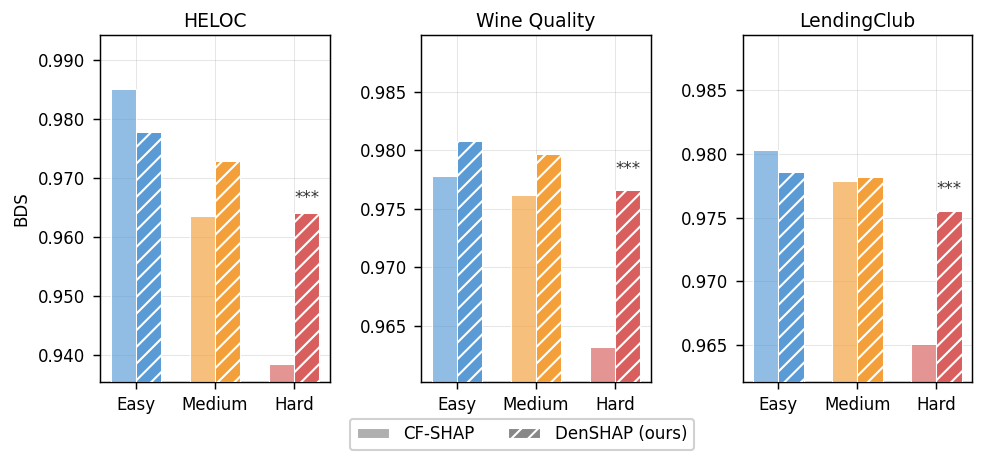

Fig 2 saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.0))
fig.subplots_adjust(wspace=0.40)

x     = np.arange(3)   # Three difficulty groups
width = 0.32            # Bar width

for col, (bdf, title) in enumerate(zip(BDS_DFS, TITLES)):
    ax = axes[col]

    cf_vals  = [bdf.loc[bdf['Group'] == g, 'CF_SHAP_BDS'].values[0]  for g in GROUPS]
    den_vals = [bdf.loc[bdf['Group'] == g, 'DenSHAP_BDS'].values[0] for g in GROUPS]

    # CF-SHAP bars: semi-transparent (hex alpha suffix 'AA' ≈ 67% opacity)
    semi_colors = [C_EASY + 'AA', C_MED + 'AA', C_HARD + 'AA']
    ax.bar(x - width / 2, cf_vals, width, color=semi_colors,
           edgecolor='white', linewidth=0.5, zorder=3)

    # DenSHAP bars: full opacity + hatch
    ax.bar(x + width / 2, den_vals, width, color=[C_EASY, C_MED, C_HARD],
           edgecolor='white', linewidth=0.5, hatch='///', zorder=3)

    # Significance annotation on the Hard group (p < 0.001 confirmed by Wilcoxon test)
    hard_top = max(
        bdf.loc[bdf['Group'] == 'Hard', 'CF_SHAP_BDS'].values[0],
        bdf.loc[bdf['Group'] == 'Hard', 'DenSHAP_BDS'].values[0]
    ) + 0.001
    ax.annotate('***', xy=(2 + width / 2, hard_top),
                ha='center', va='bottom', fontsize=8, color='#333333')

    ax.set_ylim(min(cf_vals + den_vals) - 0.003, max(cf_vals + den_vals) + 0.009)
    ax.set_xticks(x)
    ax.set_xticklabels(GROUPS, fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
    ax.set_title(title, fontsize=9, fontweight='normal', pad=4)
    ax.set_axisbelow(True)
    if col == 0:
        ax.set_ylabel('BDS', fontsize=8)

legend_patches2 = [
    mpatches.Patch(facecolor='#888888AA', edgecolor='white', label='CF-SHAP'),
    mpatches.Patch(facecolor='#888888',   edgecolor='white', hatch='///', label='DenSHAP (ours)'),
]
fig.legend(handles=legend_patches2, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=8,
           framealpha=0.9, edgecolor='#cccccc')

plt.savefig(f'{FIGURE_DIR}/fig2_bds_by_group.pdf', format='pdf')
plt.savefig(f'{FIGURE_DIR}/fig2_bds_by_group.png', format='png', dpi=600)
plt.show()
print('Fig 2 saved.')

## Fig 3 — LOF Score Distribution by Difficulty Group (Box + Jitter)

Visualises the LOF score spread within each difficulty group per dataset.  
The narrow IQR in Wine Quality (Easy/Medium groups) provides visual evidence for the CA reversal phenomenon discussed in Section 5.

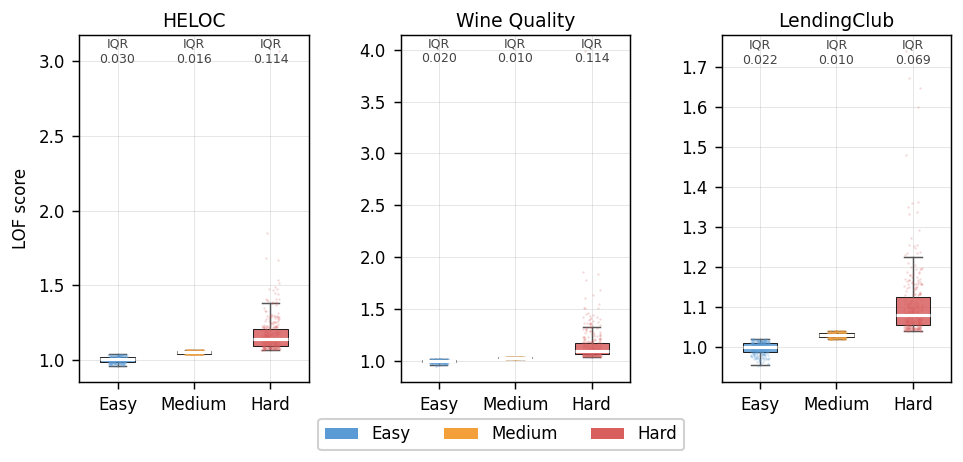

Fig 3 saved.


In [5]:
den_datasets = [
    ('HELOC',        heloc_den),
    ('Wine Quality', wine_den),
    ('LendingClub',  lc_den),
]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.0))
fig.subplots_adjust(wspace=0.40)

for col, (title, den) in enumerate(den_datasets):
    ax = axes[col]

    # Collect LOF scores per difficulty group
    data_by_group = [
        den.loc[den['difficulty_group'] == g, 'lof_score'].values
        for g in GROUPS
    ]

    # Box plot (no fliers — outliers shown via jitter instead)
    bp = ax.boxplot(
        data_by_group, positions=[1, 2, 3], widths=0.45,
        patch_artist=True, showfliers=False,
        medianprops=dict(color='white', linewidth=1.5),
        whiskerprops=dict(linewidth=0.7, color='#555555'),
        capprops=dict(linewidth=0.7, color='#555555'),
        boxprops=dict(linewidth=0.5)
    )
    for patch, color in zip(bp['boxes'], [C_EASY, C_MED, C_HARD]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    # Jittered strip plot (randomly sampled, capped at 300 points per group)
    rng = np.random.default_rng(42)   # Fixed seed for reproducibility
    for idx, (gd, color) in enumerate(zip(data_by_group, [C_EASY, C_MED, C_HARD])):
        n      = min(len(gd), 300)
        sample = rng.choice(gd, size=n, replace=False)
        jitter = rng.uniform(-0.12, 0.12, size=n)
        ax.scatter(idx + 1 + jitter, sample, s=1.2, color=color,
                   alpha=0.25, linewidths=0, zorder=2)

    # IQR annotation at the top of each group
    for idx, gd in enumerate(data_by_group):
        q1, q3 = np.percentile(gd, [25, 75])
        ax.text(idx + 1, ax.get_ylim()[1] * 0.995,
                f'IQR\n{q3 - q1:.3f}',
                ha='center', va='top', fontsize=6, color='#444444', linespacing=1.2)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(GROUPS, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='normal', pad=4)
    ax.set_axisbelow(True)
    if col == 0:
        ax.set_ylabel('LOF score', fontsize=8)

legend_patches3 = [
    mpatches.Patch(facecolor=c, label=g)
    for c, g in zip([C_EASY, C_MED, C_HARD], GROUPS)
]
fig.legend(handles=legend_patches3, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.06), fontsize=8,
           framealpha=0.9, edgecolor='#cccccc')

plt.savefig(f'{FIGURE_DIR}/fig3_lof_distribution.pdf', format='pdf')
plt.savefig(f'{FIGURE_DIR}/fig3_lof_distribution.png', format='png', dpi=600)
plt.show()
print('Fig 3 saved.')

## Fig 4 — Per-Instance ΔBDS Violin Plot (DenSHAP − CF-SHAP)

Positive ΔBDS indicates DenSHAP selects a denser background dataset.  
The distribution skews positive in the Hard group across all three datasets, supporting the core claim.  
`***` denotes p < 0.001 (Wilcoxon signed-rank test, one-sided, alternative='greater').

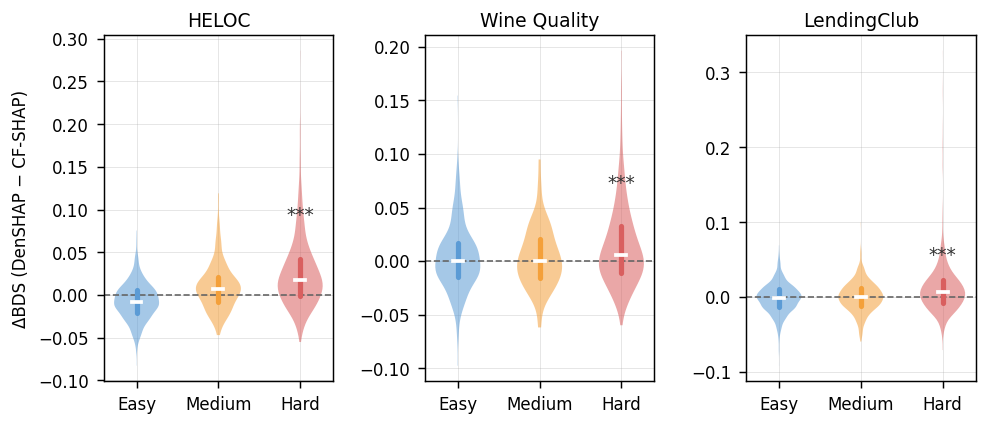

Fig 4 saved.


In [6]:
cf_den_pairs = [
    ('HELOC',        heloc_cf, heloc_den),
    ('Wine Quality', wine_cf,  wine_den),
    ('LendingClub',  lc_cf,    lc_den),
]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.0))
fig.subplots_adjust(wspace=0.40)

for col, (title, cf, den) in enumerate(cf_den_pairs):
    ax = axes[col]

    # Compute per-instance BDS difference
    diff = (den['DenSHAP_bds'] - cf['CF_SHAP_bds']).values

    # Split differences by difficulty group, removing NaNs
    grp_diffs = []
    for g in GROUPS:
        mask = den['difficulty_group'].values == g
        d    = diff[mask]
        grp_diffs.append(d[~np.isnan(d)])

    for pos, gd, color in zip([1, 2, 3], grp_diffs, [C_EASY, C_MED, C_HARD]):
        if len(gd) < 2:
            continue

        # Violin body
        parts = ax.violinplot([gd], positions=[pos], widths=0.55,
                              showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.55)
            pc.set_edgecolor('none')

        # IQR bar and median marker overlaid on the violin
        q1, med, q3 = np.percentile(gd, [25, 50, 75])
        ax.plot([pos - 0.06, pos + 0.06], [med, med],
                color='white', linewidth=1.8, zorder=5)
        ax.plot([pos, pos], [q1, q3], color=color,
                linewidth=2.5, solid_capstyle='round', zorder=4)

    # Reference line at zero (no change)
    ax.axhline(0, color='#666666', linewidth=0.8, linestyle='--', zorder=1)

    # Significance annotation on Hard group
    hard_d = grp_diffs[2]
    if len(hard_d) > 0:
        top = np.percentile(hard_d, 90)
        ax.text(3, top + 0.002, '***', ha='center', va='bottom',
                fontsize=9, color='#333333')

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(GROUPS, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='normal', pad=4)
    ax.set_axisbelow(True)
    if col == 0:
        ax.set_ylabel('ΔBDS (DenSHAP − CF-SHAP)', fontsize=8)

plt.savefig(f'{FIGURE_DIR}/fig4_bds_delta_violin.pdf', format='pdf')
plt.savefig(f'{FIGURE_DIR}/fig4_bds_delta_violin.png', format='png', dpi=600)
plt.show()
print('Fig 4 saved.')

## Fig 5 — Difficulty Score α vs. ΔBDS Scatter

Each point represents one query instance. The black line shows bin-mean trend (three equal-width bins).  
An upward trend confirms that DenSHAP's advantage grows as instance difficulty increases.

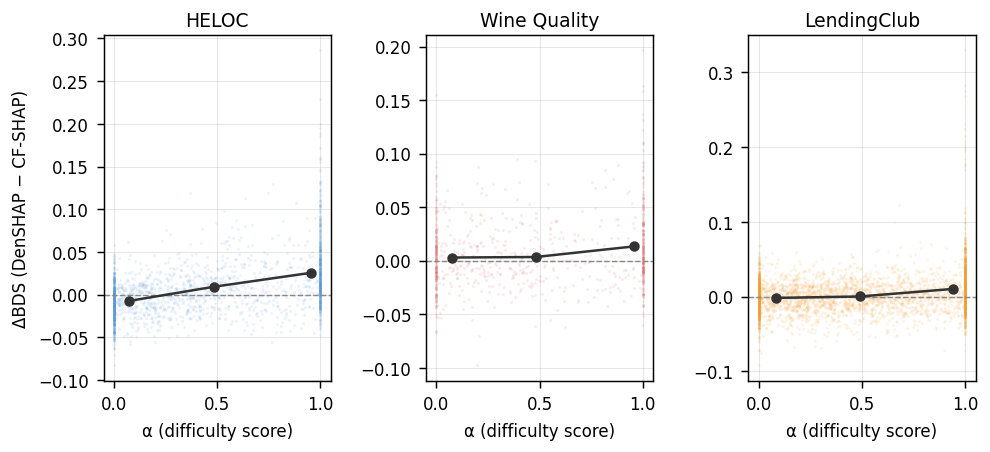

Fig 5 saved.


In [7]:
alpha_triples = [
    ('HELOC',        heloc_cf, heloc_den, '#5B9BD5'),
    ('Wine Quality', wine_cf,  wine_den,  '#D95F5F'),
    ('LendingClub',  lc_cf,    lc_den,    '#F4A03A'),
]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.0))
fig.subplots_adjust(wspace=0.42)

for col, (title, cf, den, color) in enumerate(alpha_triples):
    ax    = axes[col]
    alpha = den['alpha'].values
    delta = (den['DenSHAP_bds'] - cf['CF_SHAP_bds']).values

    # Remove NaN entries
    valid         = ~np.isnan(delta) & ~np.isnan(alpha)
    alpha, delta  = alpha[valid], delta[valid]

    # Compute bin-mean trend across three equal-width bins of α
    bins   = [0.0, 0.33, 0.67, 1.01]
    bin_x, bin_y = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (alpha >= lo) & (alpha < hi)
        if mask.sum() > 0:
            bin_x.append(alpha[mask].mean())
            bin_y.append(delta[mask].mean())

    # Raw scatter (heavily subsampled visually via low alpha)
    ax.scatter(alpha, delta, s=2, color=color, alpha=0.12, linewidths=0, zorder=2)
    # Bin-mean trend line
    ax.plot(bin_x, bin_y, 'o-', color='#333333', markersize=4,
            linewidth=1.2, zorder=5, label='Bin mean')
    # Zero-change reference line
    ax.axhline(0, color='#888888', linewidth=0.7, linestyle='--')

    ax.set_xlabel('α (difficulty score)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='normal', pad=4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_axisbelow(True)
    if col == 0:
        ax.set_ylabel('ΔBDS (DenSHAP − CF-SHAP)', fontsize=8)

plt.savefig(f'{FIGURE_DIR}/fig5_alpha_vs_delta_bds.pdf', format='pdf')
plt.savefig(f'{FIGURE_DIR}/fig5_alpha_vs_delta_bds.png', format='png', dpi=600)
plt.show()
print('Fig 5 saved.')

## Fig 6 — Plausibility Comparison (CF-SHAP vs. DenSHAP)

Box plots of per-instance plausibility scores. Lower is better (smaller distance to the query).  
Significance brackets report Wilcoxon signed-rank test results: `***` p < 0.001, `**` p < 0.01, `*` p < 0.05, `n.s.` not significant.

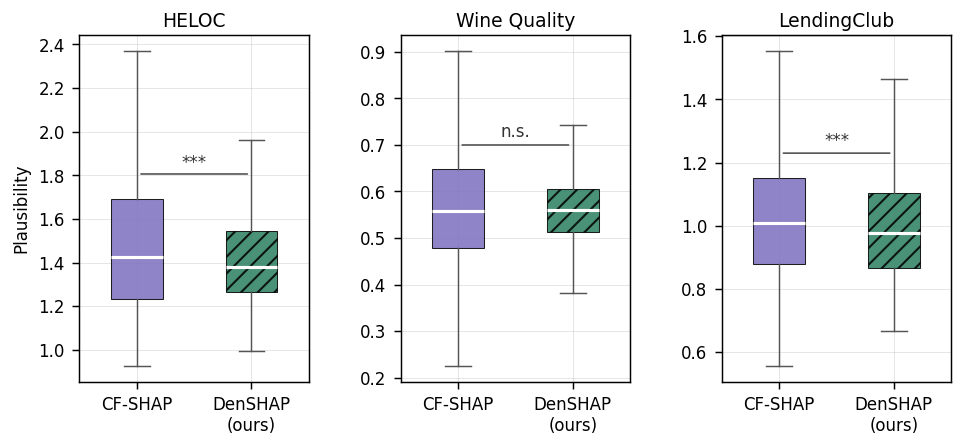

Fig 6 saved.


In [8]:
plaus_triples = [
    ('HELOC',        heloc_cf, heloc_den),
    ('Wine Quality', wine_cf,  wine_den),
    ('LendingClub',  lc_cf,    lc_den),
]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.0))
fig.subplots_adjust(wspace=0.40)

for col, (title, cf, den) in enumerate(plaus_triples):
    ax    = axes[col]
    cf_p  = cf['CF_SHAP_plausibility'].dropna().values
    den_p = den['DenSHAP_plausibility'].dropna().values

    bp = ax.boxplot(
        [cf_p, den_p], positions=[1, 2], widths=0.45,
        patch_artist=True, showfliers=False,
        medianprops=dict(color='white', linewidth=1.5),
        whiskerprops=dict(linewidth=0.7, color='#555555'),
        capprops=dict(linewidth=0.7, color='#555555'),
        boxprops=dict(linewidth=0.5)
    )
    bp['boxes'][0].set_facecolor(C_CF);  bp['boxes'][0].set_alpha(0.85)
    bp['boxes'][1].set_facecolor(C_DEN); bp['boxes'][1].set_alpha(0.85)
    bp['boxes'][1].set_hatch('///')   # Hatch on DenSHAP for B&W print

    # Wilcoxon signed-rank test (two-sided; test whether distributions differ)
    n          = min(len(cf_p), len(den_p))
    _, p       = stats.wilcoxon(den_p[:n], cf_p[:n])
    star       = ('***' if p < 0.001 else
                  '**'  if p < 0.01  else
                  '*'   if p < 0.05  else 'n.s.')

    # Significance bracket: position above the higher of the two 75th percentiles
    top = (max(np.percentile(cf_p, 75), np.percentile(den_p, 75))
           + max(np.std(cf_p), np.std(den_p)) * 0.3)
    ax.annotate('', xy=(2, top), xytext=(1, top),
                arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8))
    ax.text(1.5, top + 0.01, star, ha='center', va='bottom',
            fontsize=8, color='#333333')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['CF-SHAP', 'DenSHAP\n(ours)'], fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='normal', pad=4)
    ax.set_axisbelow(True)
    if col == 0:
        ax.set_ylabel('Plausibility', fontsize=8)

plt.savefig(f'{FIGURE_DIR}/fig6_plausibility.pdf', format='pdf')
plt.savefig(f'{FIGURE_DIR}/fig6_plausibility.png', format='png', dpi=600)
plt.show()
print('Fig 6 saved.')

## Output Verification

In [9]:
from PIL import Image

# Column headers — defined as plain strings to avoid f-string quote conflicts
# (f-string nesting with same-quote strings raises SyntaxError in Python < 3.12)
h1, h2, h3, h4 = 'Filename', 'Size (KB)', 'Dimensions', 'DPI'
print(f'{h1:<42} {h2:>10}  {h3:>18}  {h4:>12}')
print('-' * 88)

for fname in sorted(os.listdir(FIGURE_DIR)):
    fpath = os.path.join(FIGURE_DIR, fname)
    size  = os.path.getsize(fpath) // 1024

    if fname.endswith('.png'):
        img     = Image.open(fpath)
        dims    = f'{img.size[0]} x {img.size[1]} px'
        dpi_raw = img.info.get('dpi', ('N/A', 'N/A'))
        dpi_str = f'{dpi_raw[0]:.0f} DPI' if isinstance(dpi_raw[0], float) else 'N/A'
        print(f'{fname:<42} {size:>10} KB  {dims:>18}  {dpi_str:>12}')
    else:
        vec, dash = '(vector PDF)', '-'
        print(f'{fname:<42} {size:>10} KB  {vec:>18}  {dash:>12}')

Filename                                    Size (KB)          Dimensions           DPI
----------------------------------------------------------------------------------------
fig1_overall_ca_bds.pdf                            21 KB        (vector PDF)             -
fig1_overall_ca_bds.png                           480 KB      4616 x 2971 px       600 DPI
fig2_bds_by_group.pdf                              19 KB        (vector PDF)             -
fig2_bds_by_group.png                             257 KB      3932 x 1845 px       600 DPI
fig3_lof_distribution.pdf                          57 KB        (vector PDF)             -
fig3_lof_distribution.png                         252 KB      3847 x 1845 px       600 DPI
fig4_bds_delta_violin.pdf                          32 KB        (vector PDF)             -
fig4_bds_delta_violin.png                         257 KB      3945 x 1696 px       600 DPI
fig5_alpha_vs_delta_bds.pdf                       110 KB        (vector PDF)             -
fig5

In [10]:
import pandas as pd

for ds in ['heloc', 'wine', 'lendingclub']:
    df = pd.read_csv(f'results/klof20/{ds}_summary.csv', index_col='Method')
    print(f"\n=== {ds.upper()} ===")
    print(df[['CA_top1', 'BDS']].round(4).to_string())


=== HELOC ===
                CA_top1     BDS
Method                         
SHAP_TRAIN       9.4789  0.9433
SHAP_D_LAB       9.3266  0.9444
SHAP_D_PRED      9.2442  0.9438
CF_SHAP          9.1955  0.9647
DenSHAP (ours)   9.1249  0.9720

=== WINE ===
                CA_top1     BDS
Method                         
SHAP_TRAIN       9.4626  0.9614
SHAP_D_LAB       9.2150  0.9629
SHAP_D_PRED      9.2038  0.9629
CF_SHAP          8.7701  0.9720
DenSHAP (ours)   9.0553  0.9791

=== LENDINGCLUB ===
                CA_top1     BDS
Method                         
SHAP_TRAIN       9.5673  0.9663
SHAP_D_LAB       9.4482  0.9667
SHAP_D_PRED      9.3526  0.9664
CF_SHAP          9.2890  0.9738
DenSHAP (ours)   9.2153  0.9773
